In [53]:
!pip install kaggle


In [54]:
#using kagle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download krishuppal/helmet-detection

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
 99% 765M/775M [00:11<00:00, 123MB/s]
100% 775M/775M [00:11<00:00, 72.6MB/s]


In [56]:
!unzip -q /content/dog-and-cat-classification-dataset.zip -d ./dataset

In [57]:
#!rm -rf dataset/

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import seaborn as sns


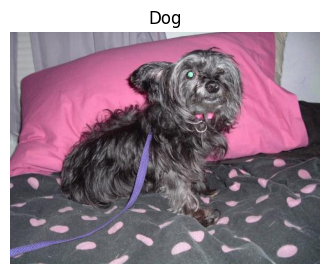

In [59]:
plt.figure(figsize=(4,4))
filepath="/content/dataset/PetImages/Dog/0.jpg"
image=imread(filepath)
plt.imshow(image)
plt.title('Dog',fontsize=12)
plt.axis('off')
plt.show()

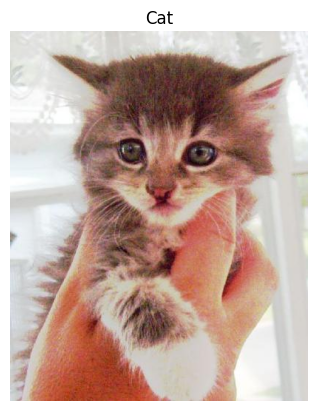

In [60]:
filepath="/content/dataset/PetImages/Cat/100.jpg"
image = imread(filepath)
plt.imshow(image)
plt.title('Cat',fontsize=12)
plt.axis('off')
plt.show()

In [63]:
import os
import shutil
from pathlib import Path

base_dir=Path("/content/dataset/PetImages")
train_dir="/content/dataset/train"
val_dir="/content/dataset/val"

os.makedirs(train_dir,exist_ok=True)
os.makedirs(val_dir,exist_ok=True)

In [64]:
#move files (80% train, 20% validation)
for category in ['Cat','Dog']:
  os.makedirs(f'{train_dir}/{category}',exist_ok=True)
  os.makedirs(f'{val_dir}/{category}',exist_ok=True)

  images=list((base_dir/category).glob("*.jpg"))[:5000]
  split=int(0.8 * len(images))

  for img in images[:split]:
    shutil.move(str(img),f"{train_dir}/{category}")

  for img in images[split:]:
    shutil.move(str(img),f"{val_dir}/{category}")

print("Dataset organized into training and validation sets.")

Dataset organized into training and validation sets.


In [72]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [66]:
# Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Create ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1.0/255)  # Only rescaling

# Load images from directory
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

Found 8000 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.


In [74]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [77]:
from typing import Optional
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512,activation='relu'),
    Dropout(0.3),
    Dense(1,activation='sigmoid')
  ])

model.compile(
      optimizer='adam',
      loss='binary_crossentropy',
      metrics=['accuracy']

)
model.summary()






/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,329 (49.36 MB)

 Trainable params: 12,939,329 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [78]:
history=model.fit(
    train_data,
    epochs=5,
    validation_data=val_data
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
183/250 ━━━━━━━━━━━━━━━━━━━━ 12s 182ms/step - accuracy: 0.5238 - loss: 0.7676

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


250/250 ━━━━━━━━━━━━━━━━━━━━ 57s 203ms/step - accuracy: 0.5335 - loss: 0.7477 - val_accuracy: 0.6085 - val_loss: 0.6616
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 188ms/step - accuracy: 0.6203 - loss: 0.6518 - val_accuracy: 0.6110 - val_loss: 0.6583
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 45s 179ms/step - accuracy: 0.6414 - loss: 0.6351 - val_accuracy: 0.6510 - val_loss: 0.6101
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 184ms/step - accuracy: 0.6561 - loss: 0.6168 - val_accuracy: 0.7230 - val_loss: 0.5628
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 46s 185ms/step - accuracy: 0.6771 - loss: 0.5927 - val_accuracy: 0.7375 - val_loss: 0.5282


In [81]:
val_loss, val_acc=model.evaluate(val_data)
print(f"Validation Accuracy:{val_acc:.2f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7221 - loss: 0.5285
Validation Accuracy:0.74


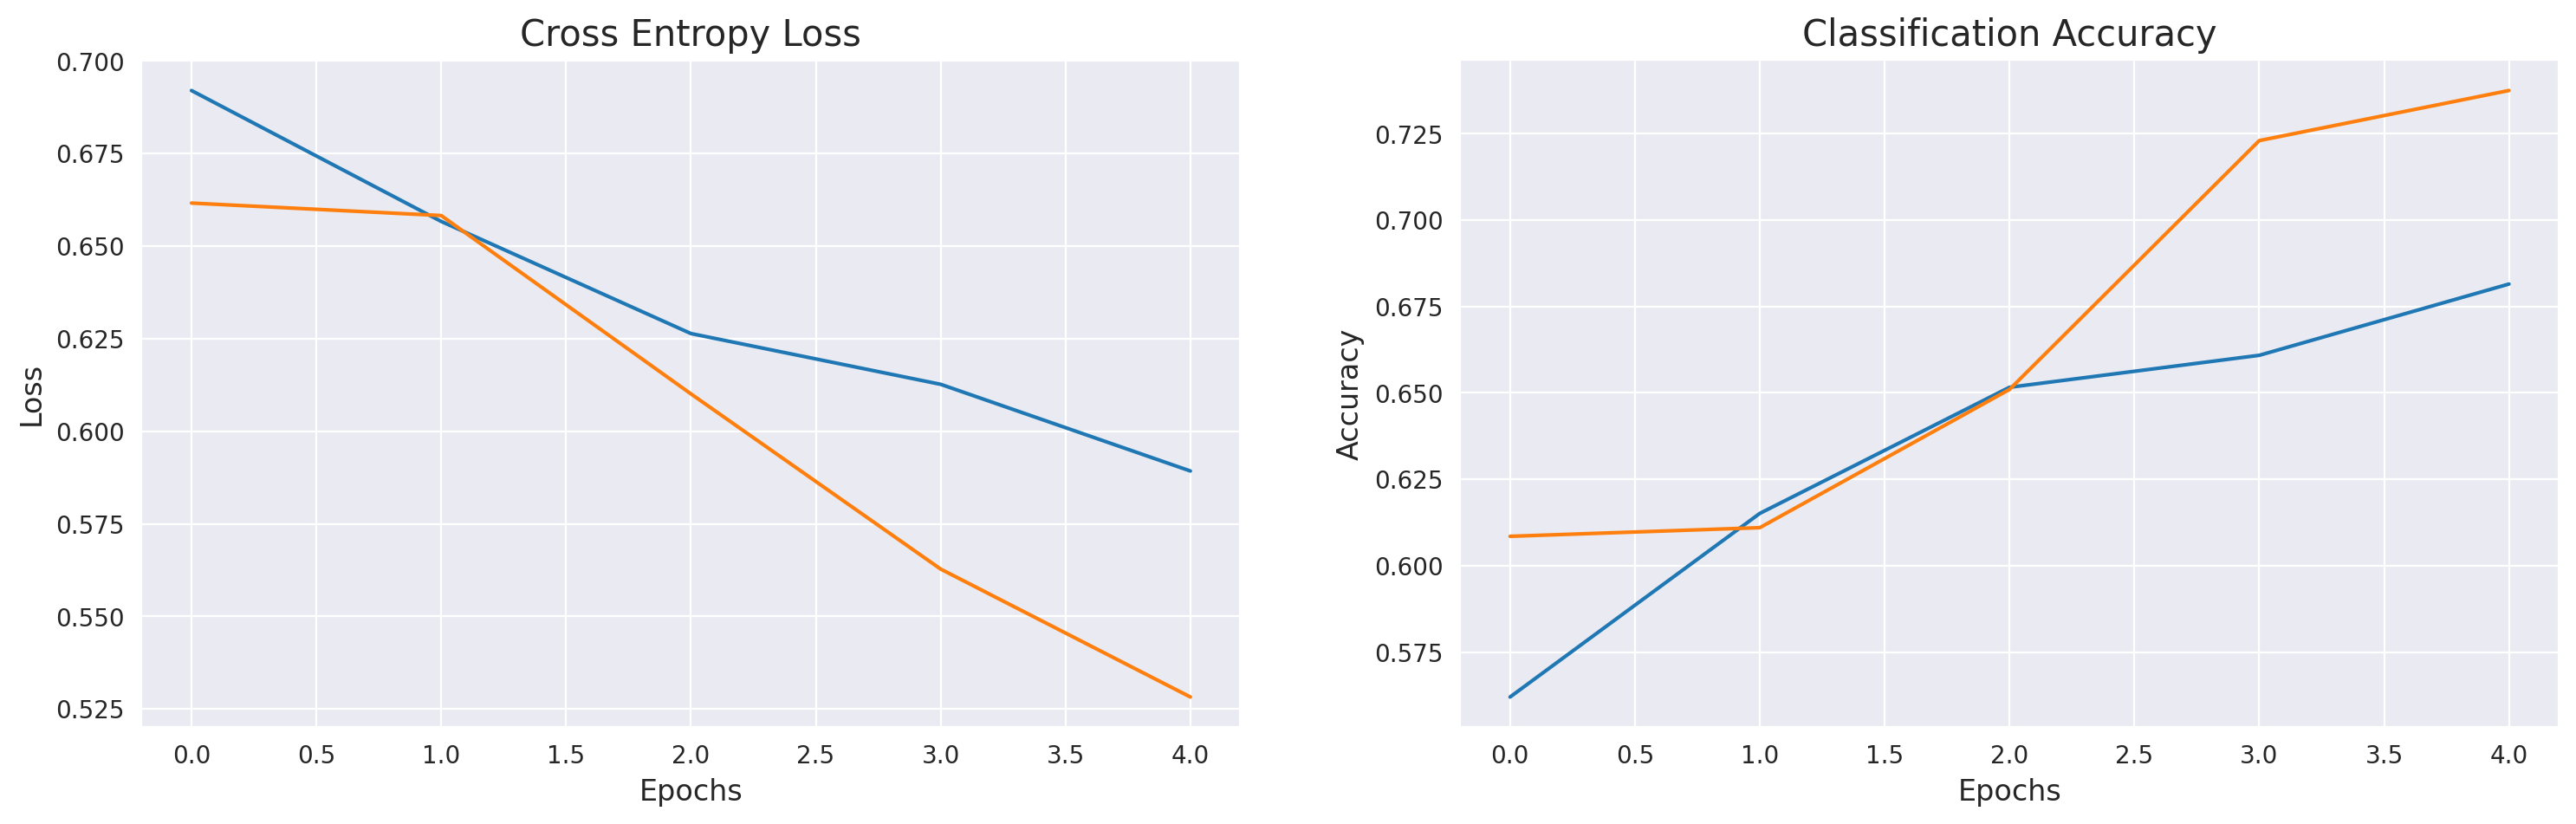

In [82]:
# plots for accuracy and Loss with epochs

error = pd.DataFrame(history.history)

plt.figure(figsize=(18,5),dpi=200)
sns.set_style('darkgrid')

plt.subplot(121)
plt.title('Cross Entropy Loss',fontsize=15)
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.plot(error['loss'])
plt.plot(error['val_loss'])

plt.subplot(122)
plt.title('Classification Accuracy',fontsize=15)
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Accuracy',fontsize=12)
plt.plot(error['accuracy'])
plt.plot(error['val_accuracy'])

plt.show()

In [86]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true=[]
y_pred=[]
steps=len(val_data)
for _ in range(steps):
    x,y=next(val_data)
    pred_probs=model.predict(x,verbose=0)
    pred_labels=(pred_probs>0.5).astype(int).flatten()

    y_true.extend(y.flatten().tolist())
    y_pred.extend(pred_labels.tolist())


y_true = np.array(y_true,dtype='int')
y_pred= np.array(y_pred,dtype='int')

cm=confusion_matrix(y_true,y_pred)
print(cm)


[[664 336]
 [189 811]]


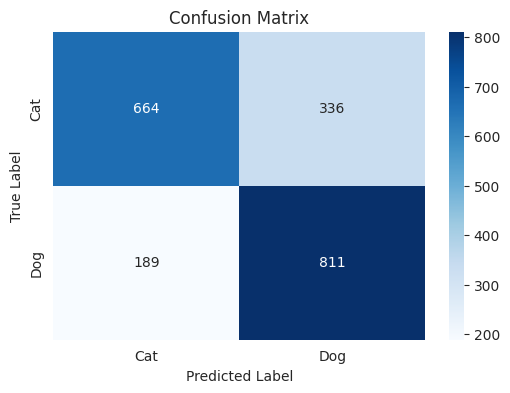

In [87]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [90]:
from sklearn.metrics import classification_report
report=classification_report(y_true,y_pred,target_names=['Cat','Dog'])
print(report)

              precision    recall  f1-score   support

         Cat       0.78      0.66      0.72      1000
         Dog       0.71      0.81      0.76      1000

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



In [91]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)  # Changed line
    img_array = tf.keras.utils.img_to_array(img) / 255.0  # Normalize # Changed line
    img_array = np.expand_dims(img_array, axis=0)  # Reshape for model

    prediction = model.predict(img_array)[0][0]
    print(prediction)
    label = "Dog" if prediction > 0.5 else "Cat"

    print(f"Prediction: {label} (Confidence: {prediction:.2f})")

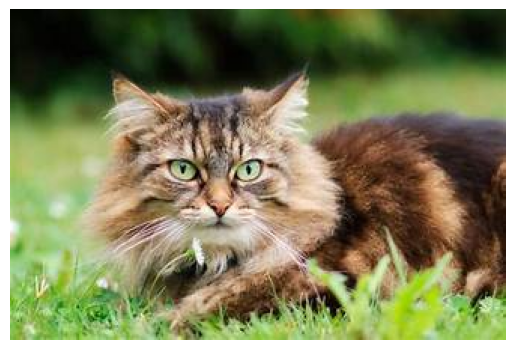

In [95]:
img_path ="cat.jpeg"
image =imread(img_path)
plt.imshow(image)
plt.axis('off')
plt.show()

In [94]:
predict_image(img_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 987ms/step
0.979396
Prediction: Dog (Confidence: 0.98)


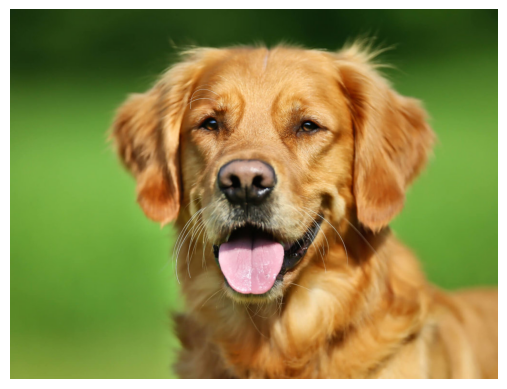

In [96]:
img_path ="dog.jpg"
image =imread(img_path)
plt.imshow(image)
plt.axis('off')
plt.show()

In [97]:
predict_image(img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
0.979396
Prediction: Dog (Confidence: 0.98)


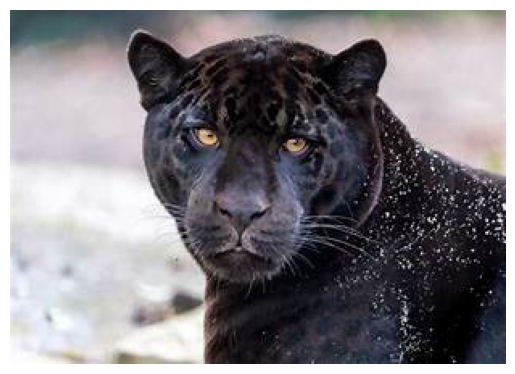

In [98]:
img_path ="panther.jpeg"
image =imread(img_path)
plt.imshow(image)
plt.axis('off')
plt.show()

In [99]:
predict_image(img_path)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
0.6781144
Prediction: Dog (Confidence: 0.68)
